In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
import seaborn as sns
import os
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv(r"C:\Users\LAHARI T\OneDrive\Attachments\Desktop\project\ayurveda_psychology_wellness_dataset.csv")
df

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,P001,37,Female,9,10,4,8,9,2,10,...,Balanced,0,4,Pitta,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Light diet, avoid fried foods",14,68,True
1,P002,40,Other,1,7,8,7,8,2,4,...,Spicy,2,2,Kapha,Vata Aggravation,"['Triphala', 'Guduchi']","Warm milk, early dinner",21,58,True
2,P003,32,Female,4,1,6,10,9,10,2,...,Spicy,1,10,Pitta-Kapha,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Cooling foods, avoid spicy",14,91,False
3,P004,53,Female,1,2,2,4,8,5,7,...,Balanced,5,5,Vata-Kapha,Vata Aggravation,"['Brahmi', 'Jatamansi']","Warm milk, early dinner",21,92,False
4,P005,48,Female,7,2,10,1,1,3,2,...,Light,1,2,Vata,Pitta Aggravation,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,P117,52,Male,6,4,3,7,8,10,9,...,Light,2,10,Vata-Pitta,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,82,True
1617,P118,69,Male,2,1,1,9,4,6,6,...,Balanced,3,8,Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,15,80,True
1618,P119,23,Female,4,9,2,6,4,2,6,...,Spicy,4,9,Kapha,Balanced,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,61,False
1619,P120,66,Female,5,8,10,7,1,3,10,...,Light,4,6,Pitta-Kapha,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,58,False


In [4]:
df.columns

Index(['patient_id', 'age', 'gender', 'stress_level', 'anxiety_level',
       'depression_score', 'maslow_physiological', 'maslow_safety',
       'maslow_social', 'maslow_esteem', 'maslow_self_actualization',
       'sleep_hours', 'exercise_frequency', 'diet_type', 'caffeine_intake',
       'screen_time_hours', 'prakriti', 'vikriti', 'herbs', 'diet_advice',
       'duration_days', 'improvement_score', 'side_effects'],
      dtype='object')

In [5]:
df.isnull().sum()

patient_id                   0
age                          0
gender                       0
stress_level                 0
anxiety_level                0
depression_score             0
maslow_physiological         0
maslow_safety                0
maslow_social                0
maslow_esteem                0
maslow_self_actualization    0
sleep_hours                  0
exercise_frequency           0
diet_type                    0
caffeine_intake              0
screen_time_hours            0
prakriti                     0
vikriti                      0
herbs                        0
diet_advice                  0
duration_days                0
improvement_score            0
side_effects                 0
dtype: int64

In [6]:
df.describe()

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,maslow_self_actualization,sleep_hours,exercise_frequency,caffeine_intake,screen_time_hours,duration_days,improvement_score
count,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000
mean,44.250463,5.644664,5.489204,5.186922,5.537323,5.417027,5.606416,5.501542,5.479951,6.061690,3.303516,2.534855,5.999383,19.874769,72.639112
std,15.545678,2.890312,2.788763,3.249156,2.881721,2.903392,2.914088,2.880463,2.810540,1.976065,2.303335,1.644910,2.599976,5.562306,13.742290
min,18.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,2.000000,14.000000,50.000000
25%,31.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,1.000000,1.000000,4.000000,15.000000,60.000000
50%,44.000000,6.000000,6.000000,5.000000,5.000000,5.000000,6.000000,6.000000,5.000000,6.000000,3.000000,3.000000,6.000000,21.000000,73.000000
75%,58.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,5.000000,4.000000,8.000000,28.000000,85.000000
max,70.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,7.000000,5.000000,10.000000,28.000000,95.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   patient_id                 1621 non-null   object
 1   age                        1621 non-null   int64 
 2   gender                     1621 non-null   object
 3   stress_level               1621 non-null   int64 
 4   anxiety_level              1621 non-null   int64 
 5   depression_score           1621 non-null   int64 
 6   maslow_physiological       1621 non-null   int64 
 7   maslow_safety              1621 non-null   int64 
 8   maslow_social              1621 non-null   int64 
 9   maslow_esteem              1621 non-null   int64 
 10  maslow_self_actualization  1621 non-null   int64 
 11  sleep_hours                1621 non-null   int64 
 12  exercise_frequency         1621 non-null   int64 
 13  diet_type                  1621 non-null   object
 14  caffeine

In [8]:
df.head()

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,P001,37,Female,9,10,4,8,9,2,10,...,Balanced,0,4,Pitta,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Light diet, avoid fried foods",14,68,True
1,P002,40,Other,1,7,8,7,8,2,4,...,Spicy,2,2,Kapha,Vata Aggravation,"['Triphala', 'Guduchi']","Warm milk, early dinner",21,58,True
2,P003,32,Female,4,1,6,10,9,10,2,...,Spicy,1,10,Pitta-Kapha,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Cooling foods, avoid spicy",14,91,False
3,P004,53,Female,1,2,2,4,8,5,7,...,Balanced,5,5,Vata-Kapha,Vata Aggravation,"['Brahmi', 'Jatamansi']","Warm milk, early dinner",21,92,False
4,P005,48,Female,7,2,10,1,1,3,2,...,Light,1,2,Vata,Pitta Aggravation,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,93,True


In [9]:
df.tail()

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
1616,P117,52,Male,6,4,3,7,8,10,9,...,Light,2,10,Vata-Pitta,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,82,True
1617,P118,69,Male,2,1,1,9,4,6,6,...,Balanced,3,8,Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,15,80,True
1618,P119,23,Female,4,9,2,6,4,2,6,...,Spicy,4,9,Kapha,Balanced,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,61,False
1619,P120,66,Female,5,8,10,7,1,3,10,...,Light,4,6,Pitta-Kapha,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,58,False
1620,P121,64,Other,1,6,10,5,4,3,2,...,Spicy,0,7,Vata,Vata Aggravation,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",14,78,True


In [10]:
df.prakriti.unique()

array(['Pitta', 'Kapha', 'Pitta-Kapha', 'Vata-Kapha', 'Vata',
       'Vata-Pitta'], dtype=object)

<Axes: xlabel='prakriti', ylabel='count'>

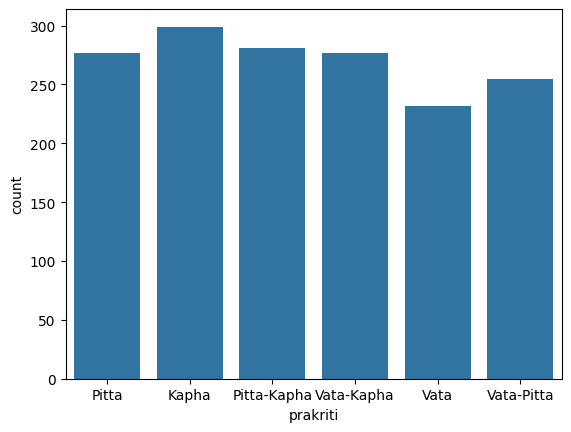

In [11]:
sns.countplot(x = 'prakriti', data = df)

In [12]:
LE =  LabelEncoder()
for i in df.columns:
    if df[i].dtypes=='object':
        df[i]=LE.fit_transform(df[i])

In [13]:
df

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,0,37,0,9,10,4,8,9,2,10,...,0,0,4,1,3,1,2,14,68,True
1,1,40,2,1,7,8,7,8,2,4,...,2,2,2,0,3,4,3,21,58,True
2,2,32,0,4,1,6,10,9,10,2,...,2,1,10,2,3,1,1,14,91,False
3,3,53,0,1,2,2,4,8,5,7,...,0,5,5,4,3,3,3,21,92,False
4,4,48,0,7,2,10,1,1,3,2,...,1,1,2,3,2,2,2,28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,116,52,1,6,4,3,7,8,10,9,...,1,2,10,5,0,4,1,21,82,True
1617,117,69,1,2,1,1,9,4,6,6,...,0,3,8,1,2,3,0,15,80,True
1618,118,23,0,4,9,2,6,4,2,6,...,2,4,9,0,0,2,2,28,61,False
1619,119,66,0,5,8,10,7,1,3,10,...,1,4,6,2,0,4,1,21,58,False


In [14]:
df.prakriti.unique()

array([1, 0, 2, 4, 3, 5])

<Axes: xlabel='prakriti', ylabel='count'>

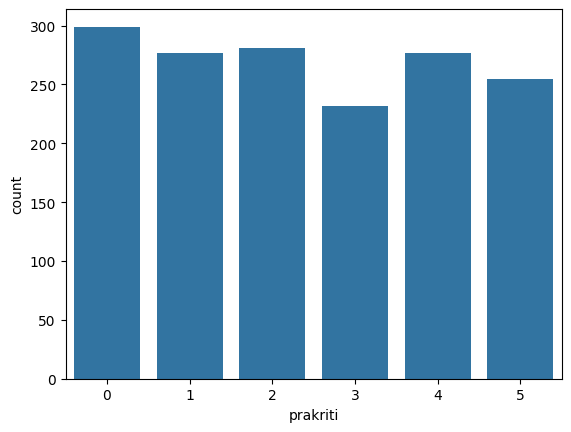

In [15]:
sns.countplot(x = 'prakriti', data = df)

<Axes: >

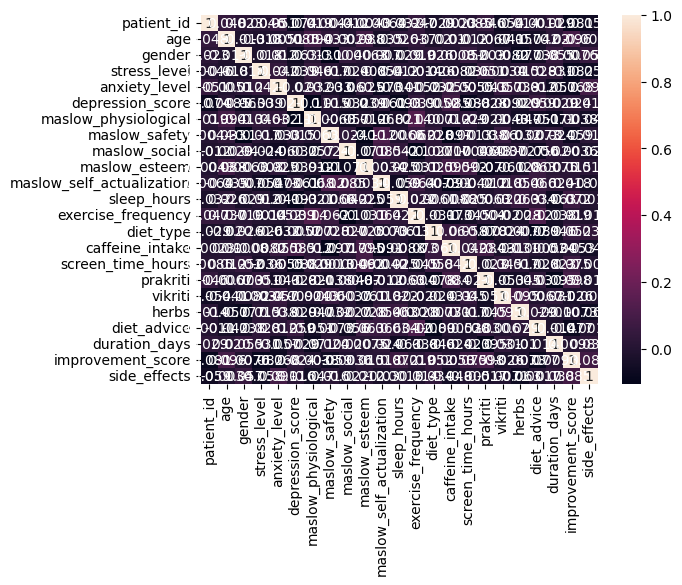

In [16]:
sns.heatmap(df.corr(), annot = True)

In [17]:
X = df.drop('prakriti', axis = 1)
X

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,exercise_frequency,diet_type,caffeine_intake,screen_time_hours,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,0,37,0,9,10,4,8,9,2,10,...,4,0,0,4,3,1,2,14,68,True
1,1,40,2,1,7,8,7,8,2,4,...,0,2,2,2,3,4,3,21,58,True
2,2,32,0,4,1,6,10,9,10,2,...,5,2,1,10,3,1,1,14,91,False
3,3,53,0,1,2,2,4,8,5,7,...,0,0,5,5,3,3,3,21,92,False
4,4,48,0,7,2,10,1,1,3,2,...,1,1,1,2,2,2,2,28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,116,52,1,6,4,3,7,8,10,9,...,6,1,2,10,0,4,1,21,82,True
1617,117,69,1,2,1,1,9,4,6,6,...,1,0,3,8,2,3,0,15,80,True
1618,118,23,0,4,9,2,6,4,2,6,...,3,2,4,9,0,2,2,28,61,False
1619,119,66,0,5,8,10,7,1,3,10,...,2,1,4,6,0,4,1,21,58,False


In [18]:
y = df['prakriti']
y

0       1
1       0
2       2
3       4
4       3
       ..
1616    5
1617    1
1618    0
1619    2
1620    3
Name: prakriti, Length: 1621, dtype: int32

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [24]:
x_train.shape

(1296, 22)

In [25]:
x_test.shape

(325, 22)

In [26]:
y_train.shape

(1296,)

In [27]:
y_test.shape

(325,)

In [28]:
precision = []
recall = []
fscore = []
accuracy = []
labels = ['Pitta', 'Kapha', 'Pitta-Kapha', 'Vata-Kapha', 'Vata',
       'Vata-Pitta']

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY, probs=None):
    testY = testY.astype('int')
    predict = predict.astype('int')

    p = precision_score(testY, predict, average='macro') * 100
    r = recall_score(testY, predict, average='macro') * 100
    f = f1_score(testY, predict, average='macro') * 100
    a = accuracy_score(testY, predict) * 100

    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)

    print(algorithm + ' Accuracy: ' + str(a))
    print(algorithm + ' Precision: ' + str(p))
    print(algorithm + ' Recall: ' + str(r))
    print(algorithm + ' FSCORE: ' + str(f))

    report = classification_report(testY, predict, target_names=labels)
    print('\n', algorithm + " classification report\n", report)

    conf_matrix = confusion_matrix(testY, predict)
    plt.figure(figsize=(5, 5))
    ax = sns.heatmap(
        conf_matrix,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        cmap="Blues",
        fmt="g"
    )
    ax.set_ylim([0, len(labels)])
    plt.title(algorithm + " Confusion Matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()


SGD Classifier Accuracy: 20.923076923076923
SGD Classifier Precision: 27.09842995169082
SGD Classifier Recall: 19.05344812124473
SGD Classifier FSCORE: 12.128518287938576

 SGD Classifier classification report
               precision    recall  f1-score   support

       Pitta       0.33      0.06      0.10        54
       Kapha       0.20      0.83      0.33        59
 Pitta-Kapha       0.40      0.04      0.07        55
  Vata-Kapha       0.50      0.02      0.05        42
        Vata       0.19      0.20      0.19        66
  Vata-Pitta       0.00      0.00      0.00        49

    accuracy                           0.21       325
   macro avg       0.27      0.19      0.12       325
weighted avg       0.26      0.21      0.13       325



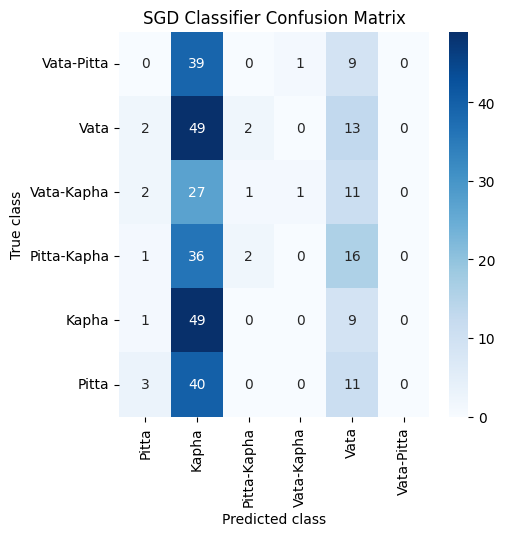

In [30]:
model = 'SGDClassifier.pkl'
if os.path.exists(model):
    SGDClassifier = joblib.load(model)
    predict = SGDClassifier.predict(x_test)
    calculateMetrics("SGD Classifier", predict, y_test)
else:
    SGDClassifier = SGDClassifier()
    SGDClassifier.fit(x_train, y_train)
    predict = SGDClassifier.predict(x_test)
    joblib.dump(SGDClassifier, model)
    print("SGDClassifier trained and model weights saved.")
    calculateMetrics("SGDClassifier", predict, y_test)

PassiveAggressiveClassifier Accuracy: 14.461538461538462
PassiveAggressiveClassifier Precision: 9.812179300997192
PassiveAggressiveClassifier Recall: 18.209876543209877
PassiveAggressiveClassifier FSCORE: 6.507764535933551

 PassiveAggressiveClassifier classification report
               precision    recall  f1-score   support

       Pitta       0.45      0.09      0.15        54
       Kapha       0.00      0.00      0.00        59
 Pitta-Kapha       0.00      0.00      0.00        55
  Vata-Kapha       0.13      1.00      0.24        42
        Vata       0.00      0.00      0.00        66
  Vata-Pitta       0.00      0.00      0.00        49

    accuracy                           0.14       325
   macro avg       0.10      0.18      0.07       325
weighted avg       0.09      0.14      0.06       325



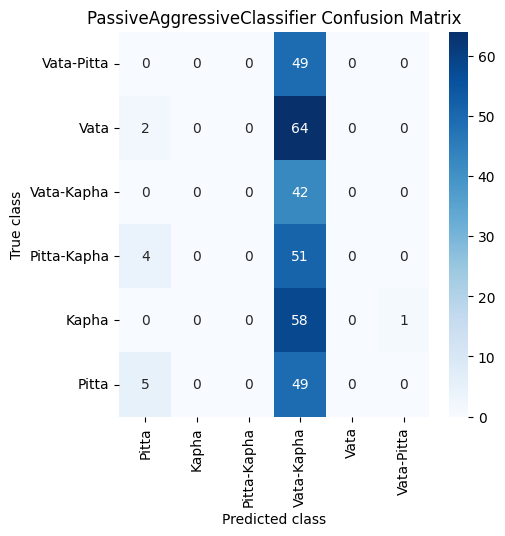

In [31]:
model = 'PassiveAggressiveClassifier.pkl'
if os.path.exists(model):
    PassiveAggressiveClassifier = joblib.load(model)
    predict = PassiveAggressiveClassifier.predict(x_test)
    calculateMetrics("PassiveAggressiveClassifier", predict, y_test)
else:
    PassiveAggressiveClassifier =PassiveAggressiveClassifier()
    PassiveAggressiveClassifier.fit(x_train, y_train)
    predict = PassiveAggressiveClassifier.predict(x_test)
    joblib.dump(PassiveAggressiveClassifier, model)
    print("PassiveAggressiveClassifier trained and model weights saved.")
    calculateMetrics("PassiveAggressiveClassifier", predict, y_test)

QuadraticDiscriminantAnalysis Accuracy: 60.92307692307693
QuadraticDiscriminantAnalysis Precision: 61.44976764652221
QuadraticDiscriminantAnalysis Recall: 60.84749838987128
QuadraticDiscriminantAnalysis FSCORE: 60.9855176893792

 QuadraticDiscriminantAnalysis classification report
               precision    recall  f1-score   support

       Pitta       0.57      0.61      0.59        54
       Kapha       0.56      0.64      0.60        59
 Pitta-Kapha       0.63      0.58      0.60        55
  Vata-Kapha       0.63      0.52      0.57        42
        Vata       0.60      0.58      0.59        66
  Vata-Pitta       0.70      0.71      0.71        49

    accuracy                           0.61       325
   macro avg       0.61      0.61      0.61       325
weighted avg       0.61      0.61      0.61       325



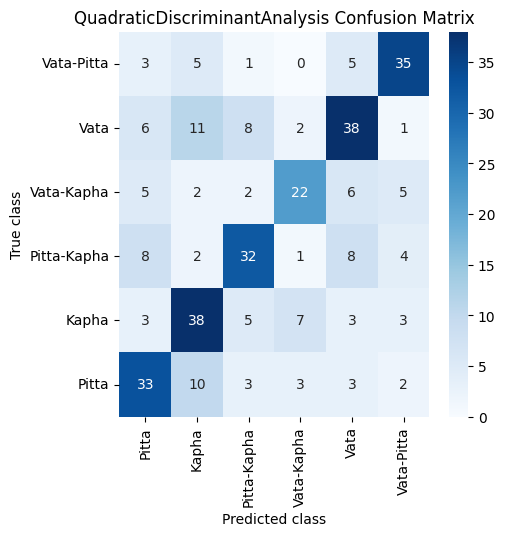

In [32]:
model = 'QuadraticDiscriminantAnalysis.pkl'
if os.path.exists(model):
    QuadraticDiscriminantAnalysis = joblib.load(model)
    predict = QuadraticDiscriminantAnalysis.predict(x_test)
    calculateMetrics("QuadraticDiscriminantAnalysis", predict, y_test)
else:
    QuadraticDiscriminantAnalysis =QuadraticDiscriminantAnalysis()
    QuadraticDiscriminantAnalysis.fit(x_train, y_train)
    predict = QuadraticDiscriminantAnalysis.predict(x_test)
    joblib.dump(QuadraticDiscriminantAnalysis, model)
    print("QuadraticDiscriminantAnalysis trained and model weights saved.")
    calculateMetrics("QuadraticDiscriminantAnalysis", predict, y_test)

ET + RF + MLP Voting Classifier Accuracy: 96.92307692307692
ET + RF + MLP Voting Classifier Precision: 97.80701754385964
ET + RF + MLP Voting Classifier Recall: 97.01449523483421
ET + RF + MLP Voting Classifier FSCORE: 97.28638717731602

 ET + RF + MLP Voting Classifier classification report
               precision    recall  f1-score   support

       Pitta       1.00      0.94      0.97        54
       Kapha       1.00      0.95      0.97        59
 Pitta-Kapha       1.00      0.93      0.96        55
  Vata-Kapha       1.00      1.00      1.00        42
        Vata       0.87      1.00      0.93        66
  Vata-Pitta       1.00      1.00      1.00        49

    accuracy                           0.97       325
   macro avg       0.98      0.97      0.97       325
weighted avg       0.97      0.97      0.97       325



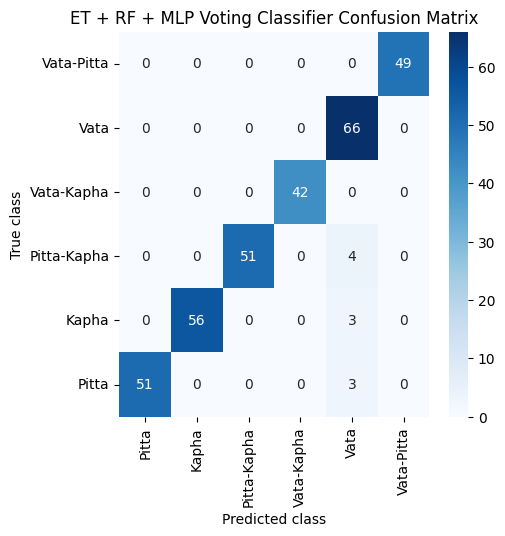

In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
import joblib
import os

model = "et_rf_mlp_voting.pkl"

if os.path.exists(model):
    voting_model = joblib.load(model)
    predict = voting_model.predict(x_test)
    probs   = voting_model.predict_proba(x_test)
    calculateMetrics("ET + RF + MLP Voting Classifier", predict, y_test, probs)

else:
    et = ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        random_state=42
    )

    voting_model = VotingClassifier(
        estimators=[
            ('et', et),
            ('rf', rf),
            ('mlp', mlp)
        ],
        voting='soft'
    )

    voting_model.fit(x_train, y_train)

    predict = voting_model.predict(x_test)
    probs   = voting_model.predict_proba(x_test)

    joblib.dump(voting_model, model)
    print("ET + RF + MLP Voting Classifier trained and model weights saved.")

    calculateMetrics("ET + RF + MLP Voting Classifier", predict, y_test, probs)


In [7]:

testdata = pd.read_csv(r"C:\Users\LAHARI T\OneDrive\Attachments\Desktop\project\python\testdata.csv")
testdata

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,exercise_frequency,diet_type,caffeine_intake,screen_time_hours,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,135,62,0,2,8,1,2,8,8,2,...,5,1,2,6,1,1,1,28,64,True
1,343,56,2,9,10,8,2,9,7,5,...,3,0,2,2,1,2,0,28,73,False
2,233,19,2,1,8,5,9,2,1,3,...,2,0,2,10,2,4,0,15,95,False
3,214,59,2,9,6,4,2,9,8,1,...,1,2,3,4,3,4,0,28,91,False
4,128,38,2,6,6,5,5,5,9,4,...,3,1,5,5,2,2,2,21,55,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,51,47,1,3,7,8,9,10,2,9,...,1,1,1,10,3,3,0,14,78,True
321,286,38,2,2,7,2,10,10,9,8,...,1,0,4,2,0,4,1,28,74,True
322,420,59,1,3,9,7,2,4,10,2,...,6,0,5,3,2,1,2,28,80,True
323,303,60,2,4,3,1,9,8,9,8,...,1,2,0,10,2,0,0,21,91,False
